In [47]:
# ============================================================
# MODULO 3 — TIME SERIES CLASSIFICATION (target: sii_binary)
# KNN euclideo + KNN DTW + Shapelet + ROCKET
# SPLIT PER SOGGETTO (GroupShuffleSplit) per evitare leakage
# ============================================================
import gzip, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm

# Ripristina plt.cm.get_cmap rimosso in matplotlib 3.9+, richiesto da scikitplot
if not hasattr(matplotlib.cm, "get_cmap"):
    matplotlib.cm.get_cmap = lambda name=None: plt.get_cmap(name)

from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_roc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_curve, auc)

with gzip.open("CMI_timeseries_dataset.pkl.gz", "rb") as f:
    CMI = pickle.load(f)

X = np.vstack([ts["enmo"].values for ts in CMI]).astype(float)
y = np.array([ts["sii_binary"].iloc[0] for ts in CMI])
groups = np.array([ts["id"].iloc[0] for ts in CMI])

# z-score per serie
Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-9)

# ── SPLIT PER SOGGETTO (critico) ─────────────────────────────
# Le 4437 finestre vengono da 494 soggetti (piu' finestre a testa).
# Uno split casuale metterebbe lo stesso soggetto in train E test ->
# il modello "riconoscerebbe la persona" invece del pattern. GroupShuffleSplit
# garantisce che ogni soggetto stia tutto in train O tutto in test.
from sklearn.model_selection import GroupShuffleSplit
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42).split(Xz, y, groups))
assert len(set(groups[tr]) & set(groups[te])) == 0   # zero soggetti condivisi

# formato 3D richiesto da sktime: (n_serie, 1 canale, 200 timestep)
X_train = Xz[tr][:, np.newaxis, :]
X_test  = Xz[te][:, np.newaxis, :]
y_train, y_test = y[tr], y[te]
class_names = ['Non-problematic', 'Problematic']
print("Train:", X_train.shape, "Test:", X_test.shape, "| test balance:", np.bincount(y_test))

Train: (3057, 1, 200) Test: (1380, 1, 200) | test balance: [871 509]


In [48]:
# ── Funzione helper: report + confusion matrix + ROC ─────────
# y_proba deve essere la matrice COMPLETA (n, 2) da predict_proba,
# perche' plot_roc (scikit-plot) vuole le probabilita' di entrambe le classi.
def eval_and_plot(y_test, y_pred, y_proba, model_name, fname_prefix):
    print(f"=== {model_name} — Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=class_names))

    cf = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cf, annot=True, cmap="Greens", fmt='d',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.tight_layout()
    plt.savefig(f'{fname_prefix}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    if y_proba is not None:
        plot_roc(y_test, y_proba)
        plt.savefig(f'{fname_prefix}_roc_curve.png', dpi=300, bbox_inches='tight')
        plt.show()

=== KNN (Euclidean) — Classification Report ===
                 precision    recall  f1-score   support

Non-problematic       0.64      0.87      0.74       871
    Problematic       0.41      0.15      0.22       509

       accuracy                           0.61      1380
      macro avg       0.53      0.51      0.48      1380
   weighted avg       0.55      0.61      0.55      1380



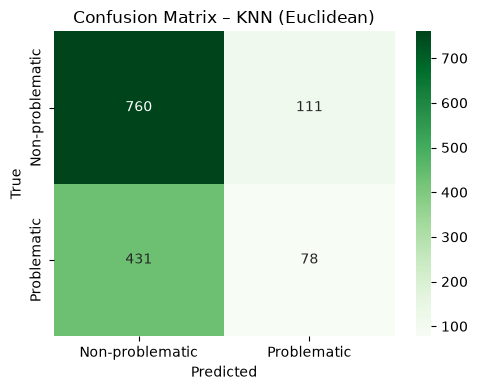

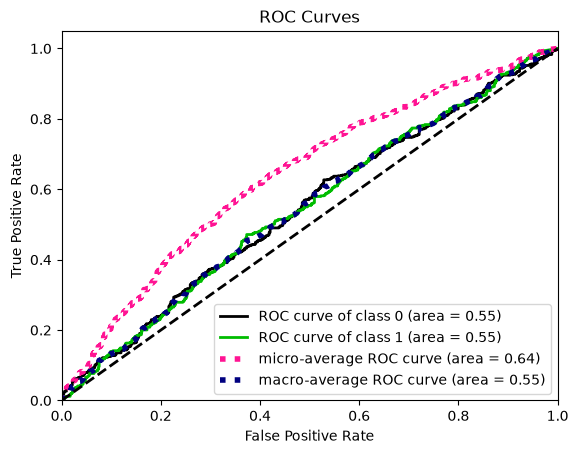

In [51]:
# ── 1. KNN con distanza EUCLIDEA ─────────────────────────────
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier

knn_eucl = KNeighborsTimeSeriesClassifier(n_neighbors=9, distance="euclidean", weights="distance")
knn_eucl.fit(X_train, y_train)
y_pred  = knn_eucl.predict(X_test)
y_proba = knn_eucl.predict_proba(X_test)          # matrice completa (n, 2)
eval_and_plot(y_test, y_pred, y_proba, "KNN (Euclidean)", "knn_eucl")

=== KNN (DTW) — Classification Report ===
                 precision    recall  f1-score   support

Non-problematic       0.63      0.91      0.75       871
    Problematic       0.40      0.10      0.16       509

       accuracy                           0.61      1380
      macro avg       0.52      0.51      0.45      1380
   weighted avg       0.55      0.61      0.53      1380



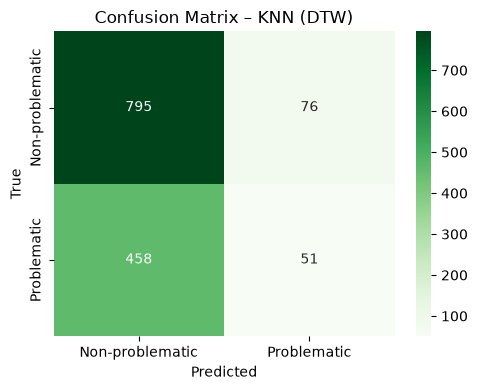

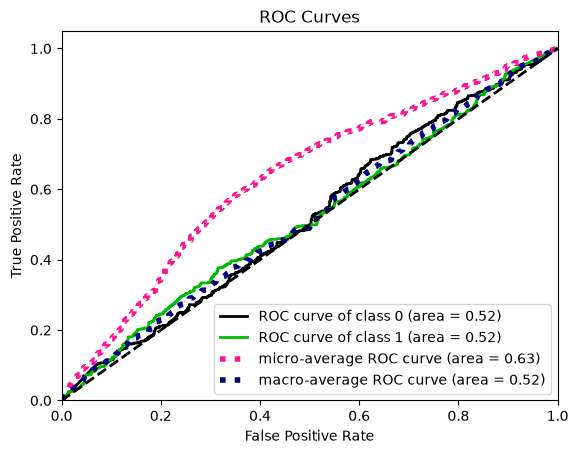

In [53]:
# ── 2. KNN con distanza DTW (vincolo Sakoe-Chiba) ────────────
# window=0.1 limita lo scostamento temporale al 10% della lunghezza:
# accelera moltissimo il DTW (altrimenti proibitivo su 4437 serie) e
# tiene conto di piccoli sfasamenti nell'orario delle attivita'.
# NOTA: questo passo e' il piu' lento (~5-6 minuti).
knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=9, distance="dtw",
                                          distance_params={"window": 0.1}, weights="distance")
knn_dtw.fit(X_train, y_train)
y_pred  = knn_dtw.predict(X_test)
y_proba = knn_dtw.predict_proba(X_test)           # matrice completa (n, 2)
eval_and_plot(y_test, y_pred, y_proba, "KNN (DTW)", "knn_dtw")

=== Shapelet + LogReg — Classification Report ===
                 precision    recall  f1-score   support

Non-problematic       0.68      0.60      0.64       871
    Problematic       0.43      0.51      0.47       509

       accuracy                           0.57      1380
      macro avg       0.55      0.56      0.55      1380
   weighted avg       0.59      0.57      0.57      1380



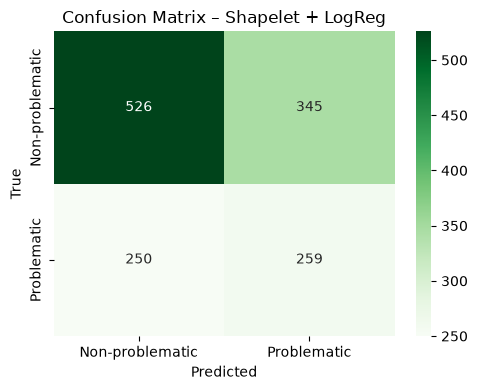

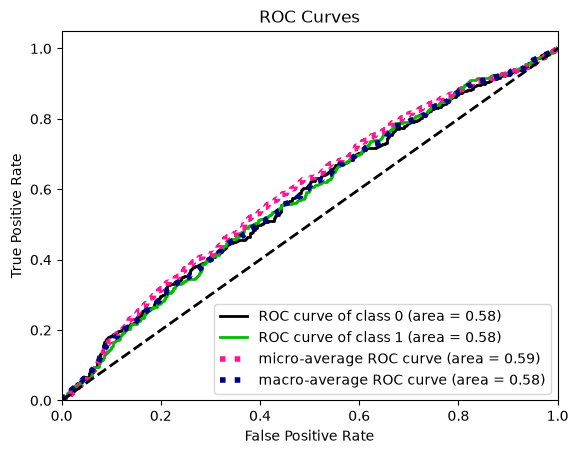

In [54]:
# ── 3. SHAPELET: RandomShapeletTransform + Logistic Regression ──
# Estrae sottosequenze discriminative (shapelet) e le usa come feature.
# time_limit contiene i tempi; class_weight='balanced' gestisce lo
# sbilanciamento (2:1 a favore dei non problematici).
from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sklearn.linear_model import LogisticRegression

stt = RandomShapeletTransform(n_shapelet_samples=300, max_shapelets=10,
                               random_state=0, n_jobs=-1, time_limit_in_minutes=3)
X_train_sh = stt.fit_transform(X_train, y_train)
X_test_sh  = stt.transform(X_test)

lr_sh = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_sh.fit(X_train_sh, y_train)
y_pred  = lr_sh.predict(X_test_sh)
y_proba = lr_sh.predict_proba(X_test_sh)          # matrice completa (n, 2)
eval_and_plot(y_test, y_pred, y_proba, "Shapelet + LogReg", "shapelet")

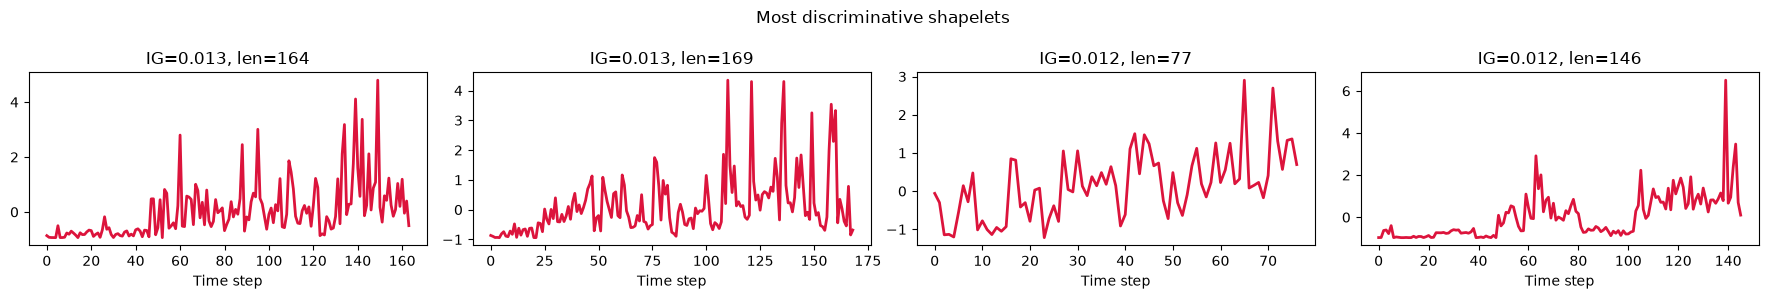

In [55]:
# ── Analisi degli shapelet estratti (richiesto dalle guidelines) ──
# Visualizzo i migliori shapelet: le "forme" piu' discriminative.
shapelets = stt.shapelets   # (info_gain, length, start_pos, ..., series_idx, ...)
top = sorted(shapelets, key=lambda s: s[0], reverse=True)[:4]

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for ax, sh in zip(axes, top):
    info_gain, length, start, series_id = sh[0], sh[1], sh[2], sh[4]
    seg = X_train[series_id, 0, start:start+length]
    ax.plot(seg, color='crimson', lw=2)
    ax.set_title(f"IG={info_gain:.3f}, len={length}")
    ax.set_xlabel("Time step")
plt.suptitle("Most discriminative shapelets")
plt.tight_layout()
plt.savefig('shapelets_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

=== ROCKET — Classification Report ===
                 precision    recall  f1-score   support

Non-problematic       0.66      0.69      0.67       871
    Problematic       0.42      0.39      0.41       509

       accuracy                           0.58      1380
      macro avg       0.54      0.54      0.54      1380
   weighted avg       0.57      0.58      0.57      1380



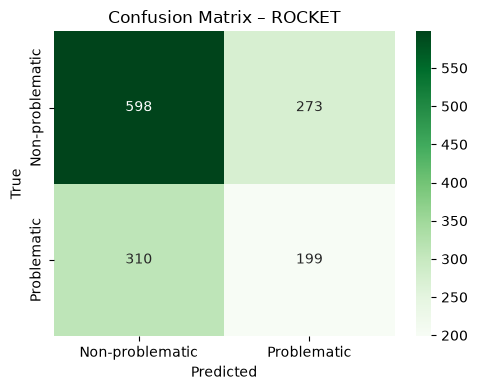

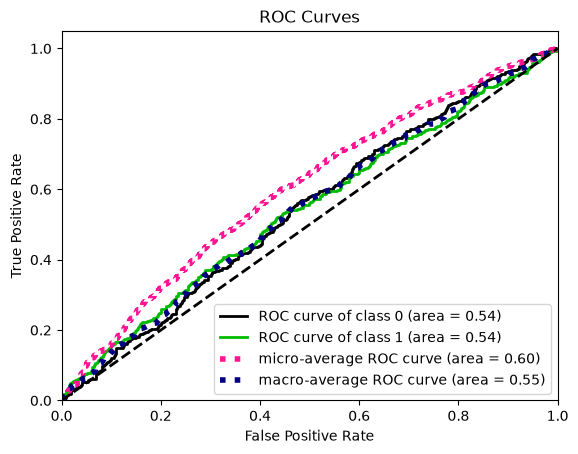

In [56]:
# ── 4. ROCKET (metodo moderno, veloce ed efficace) ───────────
# Applica migliaia di kernel convoluzionali casuali e classifica le
# feature risultanti. Uso LogisticRegression (non Ridge) come classificatore
# finale, cosi' ha predict_proba ed e' coerente con gli altri modelli (plot_roc).
from sktime.transformations.panel.rocket import Rocket
from sklearn.preprocessing import StandardScaler

rocket = Rocket(num_kernels=2000, random_state=0, n_jobs=-1)
X_train_r = rocket.fit_transform(X_train)
X_test_r  = rocket.transform(X_test)

scaler = StandardScaler()
X_train_r = scaler.fit_transform(X_train_r)
X_test_r  = scaler.transform(X_test_r)

clf_rocket = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_rocket.fit(X_train_r, y_train)
y_pred  = clf_rocket.predict(X_test_r)
y_proba = clf_rocket.predict_proba(X_test_r)      # matrice completa (n, 2)
eval_and_plot(y_test, y_pred, y_proba, "ROCKET", "rocket")